# Neuro Data pipeline

Once population responses are extracted from 2-photon imaging (`fuse.Activity.Trace`) in response to a series of visual stimulus as recorded in `stimulus.Trial` (with associated `stimulus.Condition` to specify what stimulus was presented), we must perform additional processing to associate the stimulus with the corresponding responses so that we can yield data in the form of stimulus $s$ and the associated responses of the population $\mathbf{r}$ that may be modeled as $\mathbf{r} = f(s)$.

This is precisely the job of [the `neuro_data` pipeline](https://github.com/cajal/neuro_data). Neuro data pipeline is split into two parts with highly parallel organization: `static_images` and `movies`. In this notebook, we'll take some close look at the `static_images`, but much of the discussion applies directly to the content of the `movies` subpackage.

In [53]:
import datajoint as dj
import matplotlib.pyplot as plt

get `neuro_data` package, in particular the `static_images` subpackage

In [8]:
from neuro_data.static_images import data_schemas as static, configs
fuse = dj.create_virtual_module('fuse', 'pipeline_fuse')
stimulus = dj.create_virtual_module('stimulus', 'pipeline_stimulus')

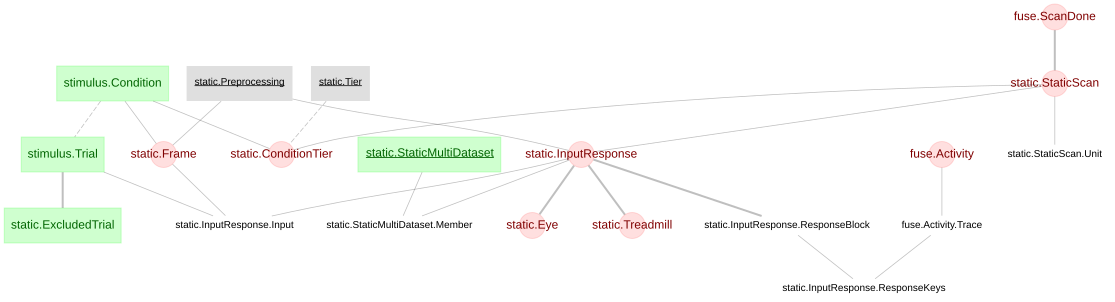

In [12]:
dj.ERD(static) + fuse.Activity + fuse.ScanDone + stimulus.Trial + stimulus.Condition

## StaticScan

Filling of `static_image` pipeline begins with filling the table `static.StaticScan` table

In [10]:
static.StaticScan()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,spike_method spike inference method
11521,7,1,1,3,5
11521,7,2,1,3,5
16157,5,5,1,3,5
16157,5,6,1,3,5
16312,3,20,1,3,5
18765,4,6,1,3,5
18765,7,17,1,6,5
20210,4,11,1,6,5
20210,5,16,1,6,5
20210,7,10,1,6,5


Filling this table with a specific scan from `fuse.ScanDone` indicates that you want that scan to go through the processing by the rest of the `neuro_data.static_images` pipeline.

### WARNING: To be changed!

At the moment, we control what scan makes it into `static.StaticScan` by adding an entry into the variable `STATIC` inside `neuro_data.static_images.data_schemas`:

In [11]:
static.STATIC

['(animal_id=11521 AND session=7 AND scan_idx in (1,2))',
 '(animal_id=16157 AND session=5 AND scan_idx in (5,6))',
 '(animal_id=11677 AND session=2 AND scan_idx=1)',
 '(animal_id=16312 AND session=3 AND scan_idx=20)',
 '(animal_id=18765 AND session=4 AND scan_idx=6)',
 '(animal_id=18765 AND session=7 AND scan_idx=17)',
 '(animal_id=20505 AND session=2 AND scan_idx=24)',
 '(animal_id=20505 AND session=3 AND scan_idx=7)',
 '(animal_id=20505 AND session=5 AND scan_idx=26)',
 '(animal_id=20505 AND session=6 AND scan_idx=1)',
 '(animal_id=20505 AND session=7 AND scan_idx=23)',
 '(animal_id=20505 AND session=7 AND scan_idx=29)',
 '(animal_id=20457 AND session=5 AND scan_idx=9)',
 '(animal_id=20457 AND session=5 AND scan_idx=17)',
 '(animal_id=20457 AND session=5 AND scan_idx=27)',
 '(animal_id=20457 AND session=7 AND scan_idx=4)',
 '(animal_id=20457 AND session=7 AND scan_idx=10)',
 '(animal_id=20457 AND session=7 AND scan_idx=16)',
 '(animal_id=20457 AND session=8 AND scan_idx=9)',
 '(anim

This approach unfortunately means that you'll have to edit the source code of `neuro_data` just to get a new scan processed, and clearly highly undesirable. You can certaintly expect a design change of this in the coming week or two. 

## static.InputResponse

One of the most important table in `static` is the `static.InputResponse`. Among other things, this tables achieves the following:

1. Align the stimulus to the activity trace
2. For each trial and for each unit, take the average activity over the specified duration and offset relative to the stimulus onset.
2. Save the resulting information into an HDF5 file to be used during neural network training.

In [15]:
keys = static.InputResponse().fetch('KEY')

In [19]:
entry = static.InputResponse & keys[0]
entry

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,spike_method spike inference method,preproc_id preprocessing ID
11521,7,1,1,3,5,0


You can find out where the file is located by invoking `get_filename()` on the target entry

In [21]:
entry.get_filename()

'/external/cache/static11521-7-1-preproc0.h5'

In [22]:
ls /external/cache/static11521-7-1-preproc0.h5

/external/cache/static11521-7-1-preproc0.h5*


When launching this Docker container, `/external` was mapped to `/mnt/scratch07`. Hence the above location actually corresponds to a file on Scratch 07.

If interested, you can directly inspect the content of the file by using HDF5 reading library like `h5py`.

Once the `InputResponse` table is filled with new scans info, one or more of `InputResponse` entries are combined into a single `StaticMultiDataset`. For inception loop experiment, a single StaticcMultiDataset with only one member (that is, only one scan) is typically used.

In [23]:
static.StaticMultiDataset()

group_id index of group,description short description of the data
0,11521-7-1
1,11521-7-2
2,16157-5-5
3,16157-5-6
4,16157-5-5-scaled
5,16312-3-20
6,11521-7-1-scaled
7,11521-7-2-scaled
8,18765-4-6
9,16157-5


Member `InputResponse` entries can be found in `Member` part table.

In [24]:
static.StaticMultiDataset.Member()

group_id index of group,animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,spike_method spike inference method,preproc_id preprocessing ID,name string description to be used for training
0,11521,7,1,1,3,5,0,group000-11521-7-1-0
1,11521,7,2,1,3,5,0,group001-11521-7-2-0
2,16157,5,5,1,3,5,0,group002-16157-5-5-0
3,16157,5,6,1,3,5,0,group003-16157-5-6-0
4,16157,5,5,1,3,5,2,group004-16157-5-5-2
5,16312,3,20,1,3,5,0,group005-16312-3-20-0
6,11521,7,1,1,3,5,2,group006-11521-7-1-2
7,11521,7,2,1,3,5,2,group007-11521-7-2-2
8,18765,4,6,1,3,5,0,group008-18765-4-6-0
9,16157,5,5,1,3,5,0,group009-16157-5-5-0


Critically, you can fetch the dataset corresponding to a particular `StaticMultiDataset` by calling `fetch_data`

In [26]:
static.StaticMultiDataset() & 'group_id = 21'

group_id index of group,description short description of the data
21,20210-4-11


In [32]:
datasets = static.StaticMultiDataset().fetch_data('group_id = 21')

21-06-2019:07:18:11 INFO     data_schemas.py      962:	 Fetching data for 'group_id = 21'
21-06-2019:07:18:11 INFO     data_schemas.py      972:	 Data will be (images,behavior,pupil_center,responses)
21-06-2019:07:18:11 INFO     data_schemas.py      975:	 Loading dataset group021-20210-4-11-0 --> /external/cache/static20210-4-11-preproc0.h5


In [33]:
datasets

OrderedDict([('group021-20210-4-11-0', Tensor images: (5998, 1, 36, 64) 
              Tensor behavior: (5998, 3) 
              Tensor pupil_center: (5998, 2) 
              Tensor responses: (5998, 8127) 
              Transforms: []
              	[Stats source: all])])

In [34]:
ds = datasets['group021-20210-4-11-0']

In [48]:
ds

Tensor images: (5998, 1, 36, 64) 
Tensor behavior: (5998, 3) 
Tensor pupil_center: (5998, 2) 
Tensor responses: (5998, 8127) 
Transforms: []
	[Stats source: all]

In [51]:
ds.images.shape # all images presented

(5998, 1, 36, 64)

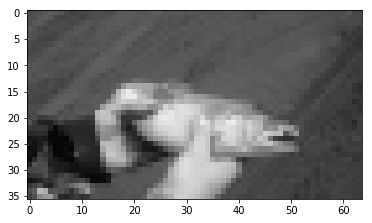

In [56]:
plt.imshow(ds.images[0].squeeze(), vmin=0, vmax=255, cmap='gray')

Eye traces for the first 30 trials

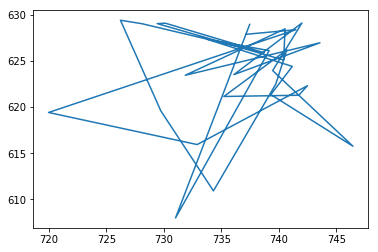

In [64]:
plt.plot(ds.pupil_center[0:30, 0], ds.pupil_center[0:30, 1])

Information about neurons can be found under `neurons` attribute

In [36]:
ds.neurons

In [45]:
ds.neurons.animal_ids

array([20210, 20210, 20210, ..., 20210, 20210, 20210], dtype=uint16)

In [46]:
ds.neurons.area

array(['V1', 'V1', 'V1', ..., 'V1', 'V1', 'V1'], dtype='<U2')

In [47]:
ds.neurons.layer

array(['L2/3', 'L2/3', 'L2/3', ..., 'L2/3', 'L2/3', 'L2/3'], dtype='<U4')

## Summary

In this notebook, we took a look at the `neuro_data` package, and saw that `StaticMultiDataset` represents trial aligned population response data from a collection of one or more scans.

We will see that `StaticMultiDataset` is then the key source training of neural networks, predicting the populations responses to each trial static image.